# 03b — Isolation Forest (Baseline)

Classical ensemble method that isolates anomalies by recursively partitioning the feature space; no temporal modelling, per-window independent scoring; serves as the reference point for the three deep learning models.

In [5]:
import warnings
import json
import ast
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm
from sklearn.ensemble import IsolationForest
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")

RANDOM_STATE    = 42
OPTUNA_TRIALS   = 20
OPTUNA_ENTITIES = 10
DATA_DIR    = Path("data/processed")
RESULTS_DIR = Path("results/baseline")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


In [6]:
with open("data/processed/metadata.json") as f:
    metadata = json.load(f)

entities    = metadata["entities"]
n_channels  = metadata["n_channels"]
window_size = metadata["window_size"]

_labels_map = {}
with open('labeled_anomalies.csv') as _f:
    for _row in csv.DictReader(_f):
        _labels_map[_row['chan_id']] = _row['spacecraft']

smap_pool = [e for e in entities if _labels_map.get(e) == 'SMAP'][:OPTUNA_ENTITIES]
msl_pool  = [e for e in entities if _labels_map.get(e) == 'MSL'][:OPTUNA_ENTITIES]

print(f"Entities: {len(entities)}  (SMAP: {sum(1 for e in entities if _labels_map.get(e)=='SMAP')}, MSL: {sum(1 for e in entities if _labels_map.get(e)=='MSL')})")
print(f"Optuna pool: {len(smap_pool)} SMAP + {len(msl_pool)} MSL")

Entities: 82  (SMAP: 54, MSL: 27)
Optuna pool: 10 SMAP + 10 MSL


## Hyperparameter Tuning with Optuna

Tuned parameters:
- `n_estimators` — number of trees in the forest {50, 100, 200, 300}
- `max_features` — fraction of features drawn per tree {0.5, 0.75, 1.0}

**Objective:** minimise the mean anomaly score on validation windows (all normal). A lower mean score means the model correctly identifies normal data as non-anomalous, i.e. the decision boundary is well-calibrated.

Tuning is run **separately for SMAP and MSL** (10 entities each) to account for the difference in channel count (25 vs 55).

In [7]:
def optuna_objective(trial, entity_id):
    n_est    = trial.suggest_categorical("n_estimators", [50, 100, 200, 300])
    max_feat = trial.suggest_categorical("max_features", [0.5, 0.75, 1.0])

    train_w = np.load(DATA_DIR / f"{entity_id}_train.npy")
    val_w   = np.load(DATA_DIR / f"{entity_id}_val.npy")

    if val_w.ndim < 3 or len(val_w) == 0:
        raise optuna.exceptions.TrialPruned()

    train_flat = train_w.reshape(len(train_w), -1)
    val_flat   = val_w.reshape(len(val_w),   -1)

    iso = IsolationForest(
        n_estimators=n_est,
        max_features=max_feat,
        contamination="auto",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    iso.fit(train_flat)

    return float(-iso.score_samples(val_flat).mean())


def run_optuna_group(entity_pool, group_name):
    valid_n_est = [50, 100, 200, 300]
    valid_mfeat = [0.5, 0.75, 1.0]
    all_params = []
    for entity_id in tqdm(entity_pool, desc=f"Optuna {group_name}"):
        study = optuna.create_study(direction="minimize")
        study.optimize(
            lambda trial, eid=entity_id: optuna_objective(trial, eid),
            n_trials=OPTUNA_TRIALS,
        )
        all_params.append(study.best_params)
        print(f"  {entity_id}: val_score={study.best_value:.4f}, params={study.best_params}")
    avg_n = np.mean([p["n_estimators"] for p in all_params])
    avg_f = np.mean([p["max_features"] for p in all_params])
    return {
        "n_estimators": min(valid_n_est, key=lambda v: abs(v - avg_n)),
        "max_features": min(valid_mfeat, key=lambda v: abs(v - avg_f)),
    }


best_params_smap = run_optuna_group(smap_pool, "SMAP")
with open(RESULTS_DIR / "best_params_smap.json", "w") as f:
    json.dump(best_params_smap, f, indent=2)
print(f"\nSMAP: {best_params_smap}")

best_params_msl = run_optuna_group(msl_pool, "MSL")
with open(RESULTS_DIR / "best_params_msl.json", "w") as f:
    json.dump(best_params_msl, f, indent=2)
print(f"MSL:  {best_params_msl}")


Optuna SMAP:   0%|          | 0/10 [00:00<?, ?it/s]

  A-1: val_score=0.3576, params={'n_estimators': 300, 'max_features': 1.0}
  A-2: val_score=0.3823, params={'n_estimators': 50, 'max_features': 0.75}
  A-3: val_score=0.3797, params={'n_estimators': 50, 'max_features': 1.0}
  A-4: val_score=0.3835, params={'n_estimators': 50, 'max_features': 1.0}
  A-5: val_score=0.3302, params={'n_estimators': 50, 'max_features': 1.0}
  A-6: val_score=0.3354, params={'n_estimators': 100, 'max_features': 1.0}
  A-7: val_score=0.3197, params={'n_estimators': 100, 'max_features': 0.75}
  A-8: val_score=0.4312, params={'n_estimators': 100, 'max_features': 1.0}
  A-9: val_score=0.4373, params={'n_estimators': 50, 'max_features': 0.75}
  B-1: val_score=0.2878, params={'n_estimators': 50, 'max_features': 0.5}

SMAP: {'n_estimators': 100, 'max_features': 0.75}


Optuna MSL:   0%|          | 0/10 [00:00<?, ?it/s]

  C-1: val_score=0.3419, params={'n_estimators': 200, 'max_features': 0.75}
  C-2: val_score=0.4026, params={'n_estimators': 100, 'max_features': 0.75}
  D-14: val_score=0.4898, params={'n_estimators': 50, 'max_features': 0.5}
  D-15: val_score=0.3325, params={'n_estimators': 100, 'max_features': 0.5}
  D-16: val_score=0.3586, params={'n_estimators': 50, 'max_features': 0.75}
  F-4: val_score=0.3385, params={'n_estimators': 200, 'max_features': 0.75}
  F-5: val_score=0.3277, params={'n_estimators': 50, 'max_features': 0.75}
  F-7: val_score=0.3371, params={'n_estimators': 50, 'max_features': 0.75}
  F-8: val_score=0.3418, params={'n_estimators': 50, 'max_features': 1.0}
  M-1: val_score=0.3648, params={'n_estimators': 100, 'max_features': 0.75}
MSL:  {'n_estimators': 100, 'max_features': 0.75}


## Scoring

Each window is flattened to `(window_size × n_channels,)`. `IsolationForest` is fitted on train windows, then applied to val and test windows independently. No temporal structure is used — each window is treated as an i.i.d. sample.

`IsolationForest.score_samples()` returns higher values for *normal* points. We negate the scores so that **higher = more anomalous**, matching the convention expected by the evaluation notebook.

In [8]:
with open(RESULTS_DIR / "best_params_smap.json") as f:
    best_params_smap = json.load(f)
with open(RESULTS_DIR / "best_params_msl.json") as f:
    best_params_msl = json.load(f)

print("SMAP params:", best_params_smap)
print("MSL  params:", best_params_msl)

first_entity = True

for entity_id in tqdm(entities, desc="Isolation Forest"):
    try:
        bp = best_params_msl if _labels_map.get(entity_id) == 'MSL' else best_params_smap

        train_windows = np.load(DATA_DIR / f"{entity_id}_train.npy")
        val_windows   = np.load(DATA_DIR / f"{entity_id}_val.npy")
        test_windows  = np.load(DATA_DIR / f"{entity_id}_test.npy")

        n_train, ws, nc = train_windows.shape
        train_flat = train_windows.reshape(n_train, ws * nc)
        test_flat  = test_windows.reshape(test_windows.shape[0], ws * nc)

        if val_windows.ndim < 3 or len(val_windows) == 0:
            np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", np.array([], dtype=np.float32))
            val_flat = None
        else:
            val_flat = val_windows.reshape(val_windows.shape[0], ws * nc)

        iso = IsolationForest(
            n_estimators=bp["n_estimators"],
            max_features=bp["max_features"],
            contamination="auto",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )
        iso.fit(train_flat)

        test_scores = -iso.score_samples(test_flat).astype(np.float32)
        np.save(RESULTS_DIR / f"{entity_id}_test_scores.npy", test_scores)

        if val_flat is not None:
            val_scores = -iso.score_samples(val_flat).astype(np.float32)
            np.save(RESULTS_DIR / f"{entity_id}_val_scores.npy", val_scores)

        if first_entity:
            print(f"\n[{entity_id}] n_estimators={bp['n_estimators']}  max_features={bp['max_features']}")
            print(f"  test_scores: shape={test_scores.shape}  range=[{test_scores.min():.4f}, {test_scores.max():.4f}]")
            first_entity = False

    except Exception as exc:
        warnings.warn(f"Failed '{entity_id}': {exc}")

print("\nScoring complete.")


SMAP params: {'n_estimators': 100, 'max_features': 0.75}
MSL  params: {'n_estimators': 100, 'max_features': 0.75}


Isolation Forest:   0%|          | 0/82 [00:00<?, ?it/s]


[A-1] n_estimators=100  max_features=0.75
  test_scores: shape=(8541,)  range=[0.3057, 0.4483]

Scoring complete.


## Score Distribution (Sample Entity)

Sample entity: A-1
Val p95 threshold : 0.4001
test_scores shape : (8541,)


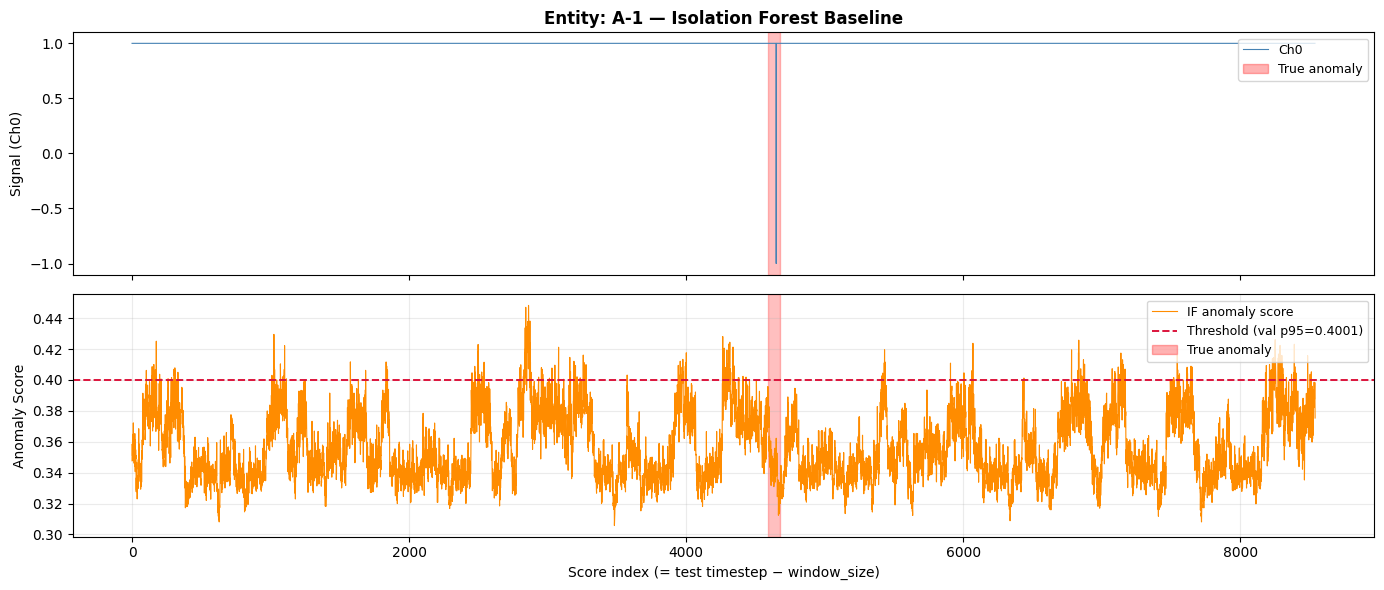


Done. Scores saved to: results/baseline


In [9]:
# ── Pick first entity from metadata ───────────────────────────────────────────
sample_entity = entities[0]
print(f"Sample entity: {sample_entity}")

# ── Load baseline scores ──────────────────────────────────────────────────────
test_scores = np.load(RESULTS_DIR / f"{sample_entity}_test_scores.npy")
val_scores  = np.load(RESULTS_DIR / f"{sample_entity}_val_scores.npy")

threshold = np.percentile(val_scores, 95) if len(val_scores) > 0 else np.percentile(test_scores, 95)
print(f"Val p95 threshold : {threshold:.4f}")
print(f"test_scores shape : {test_scores.shape}")

# ── Load labeled anomalies ────────────────────────────────────────────────────
labels_df = pd.read_csv("labeled_anomalies.csv")
labels_df["anomaly_sequences"] = labels_df["anomaly_sequences"].apply(ast.literal_eval)
sample_row = labels_df[labels_df["chan_id"] == sample_entity].iloc[0]
anomaly_seqs = sample_row["anomaly_sequences"]

# Build per-window ground-truth labels (same logic as evaluation notebook)
n_scores = len(test_scores)
test_len = n_scores + window_size
gt_labels = np.zeros(n_scores, dtype=int)
for start, end in anomaly_seqs:
    s = max(0, start - window_size)
    e = min(n_scores, end - window_size + 1)
    if e > s:
        gt_labels[s:e] = 1

# ── Try to load raw test signal ───────────────────────────────────────────────
signal = None
try:
    for candidate in [
        Path("data/test") / f"{sample_entity}.npy",
        Path("data") / f"{sample_entity}.npy",
    ]:
        if candidate.exists():
            raw = np.load(candidate)
            signal = raw[:, 0] if raw.ndim == 2 else raw
            break
except Exception as exc:
    warnings.warn(f"Could not load raw test signal: {exc}")

# ── Plot ──────────────────────────────────────────────────────────────────────
score_x = np.arange(n_scores)

def shade_anomalies(ax, labels):
    """Shade anomaly segments in red on the given axis."""
    in_seg = False
    for i, lbl in enumerate(labels):
        if lbl == 1 and not in_seg:
            seg_s = i
            in_seg = True
        elif lbl == 0 and in_seg:
            ax.axvspan(seg_s, i, alpha=0.25, color="red", label="_nolegend_")
            in_seg = False
    if in_seg:
        ax.axvspan(seg_s, len(labels), alpha=0.25, color="red")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# ── Top panel: channel 0 of test signal ──────────────────────────────────────
ax0 = axes[0]
if signal is not None:
    sig_plot = signal[window_size : window_size + n_scores]
    ax0.plot(score_x[: len(sig_plot)], sig_plot, color="steelblue", linewidth=0.8, label="Ch0")
    ax0.set_ylabel("Signal (Ch0)", fontsize=10)
    ax0.legend(fontsize=9, loc="upper right")
else:
    ax0.text(
        0.5, 0.5,
        "Raw signal not found — run data preparation notebook to save test arrays",
        ha="center", va="center", transform=ax0.transAxes,
        fontsize=10, color="grey",
    )
    ax0.set_ylabel("Signal (Ch0)", fontsize=10)
shade_anomalies(ax0, gt_labels)
anomaly_patch = mpatches.Patch(color="red", alpha=0.3, label="True anomaly")
handles, lbs = ax0.get_legend_handles_labels()
ax0.legend(handles=handles + [anomaly_patch], labels=lbs + ["True anomaly"], fontsize=9, loc="upper right")
ax0.set_title(f"Entity: {sample_entity} — Isolation Forest Baseline", fontsize=12, fontweight="bold")

# ── Bottom panel: baseline anomaly scores ────────────────────────────────────
ax1 = axes[1]
ax1.plot(score_x, test_scores, color="darkorange", linewidth=0.8, label="IF anomaly score")
ax1.axhline(threshold, color="crimson", linestyle="--", linewidth=1.4, label=f"Threshold (val p95={threshold:.4f})")
shade_anomalies(ax1, gt_labels)
anomaly_patch2 = mpatches.Patch(color="red", alpha=0.3, label="True anomaly")
handles1, lbs1 = ax1.get_legend_handles_labels()
ax1.legend(handles=handles1 + [anomaly_patch2], labels=lbs1 + ["True anomaly"], fontsize=9, loc="upper right")
ax1.set_ylabel("Anomaly Score", fontsize=10)
ax1.set_xlabel("Score index (= test timestep − window_size)", fontsize=10)
ax1.grid(alpha=0.25)

plt.tight_layout()
plt.show()

print(f"\nDone. Scores saved to: {RESULTS_DIR}")